In [1]:
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import time
import os
import gc
import warnings
import matplotlib.pyplot as plt

# Scikit-Learn tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Machine learning models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

warnings.filterwarnings("ignore")

## 1. Configuração Global do Pipeline

Use esta célula para personalizar a execução do pipeline. Altamente recomendado para executar de forma eficiente tanto em instâncias locais como em clusters Dataproc.

In [2]:
USE_SAMPLE = True             
SAMPLE_SIZE = 100000          
CV_FOLDS = 3                  
RANDOM_STATE = 42             
N_JOBS = -1                   

# GCS target paths
GCS_BUCKET = "gs://dataproc-staging-europe-southwest1-348488791616-f80l4tzf/notebooks/jupyter"
GCS_RAW_FILE = f"{GCS_BUCKET}/yellow_tripdata_2022-01.parquet"
GCS_PROCESSED_FILE = f"{GCS_BUCKET}/yellow_tripdata_2022-01_clean_ml.parquet"

# Local directory for saving plots and metric summaries
PROJECT_ROOT = Path("..").resolve()
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Reproducible state set to {RANDOM_STATE}.")
print(f"Sample size for training set to {SAMPLE_SIZE}.")
print(f"Cross-validation folds set to {CV_FOLDS}.")
print(f"Reading GCS input from: {GCS_RAW_FILE}")
print(f"Writing GCS output to: {GCS_PROCESSED_FILE}")

Reproducible state set to 42.
Sample size for training set to 100000.
Cross-validation folds set to 3.
Reading GCS input from: gs://dataproc-staging-europe-southwest1-348488791616-f80l4tzf/notebooks/jupyter/yellow_tripdata_2022-01.parquet
Writing GCS output to: gs://dataproc-staging-europe-southwest1-348488791616-f80l4tzf/notebooks/jupyter/yellow_tripdata_2022-01_clean_ml.parquet


## 2. Leitura de Dados Diretamente do Bucket GCS

Carrega o dataset bruto de Janeiro de 2022 diretamente do bucket de staging do Google Cloud Storage usando integração nativa.

In [3]:
start_time = time.perf_counter()

print(f"Streaming dataset directly from GCS: {GCS_RAW_FILE}")
df_raw = pd.read_parquet(GCS_RAW_FILE)

end_time = time.perf_counter()

print(f"Dataset successfully loaded in {end_time - start_time:.4f} seconds.")
print(f"Initial shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns.")

Streaming dataset directly from GCS: gs://dataproc-staging-europe-southwest1-348488791616-f80l4tzf/notebooks/jupyter/yellow_tripdata_2022-01.parquet
Dataset successfully loaded in 0.6306 seconds.
Initial shape: 2,463,931 rows x 19 columns.


## 3. Pré-processamento, Limpeza de Dados e Filtragem de Outliers

Para construir um modelo de machine learning robusto e de alto desempenho, limpamos o dataset removendo registos falsos, outliers e valores irrealistas:

In [4]:
initial_rows = len(df_raw)

# 1. Feature Engineering (Calculating duration and time fractions)
df_raw['tpep_pickup_datetime'] = pd.to_datetime(df_raw['tpep_pickup_datetime'])
df_raw['tpep_dropoff_datetime'] = pd.to_datetime(df_raw['tpep_dropoff_datetime'])

df_raw['trip_duration_minutes'] = (df_raw['tpep_dropoff_datetime'] - df_raw['tpep_pickup_datetime']).dt.total_seconds() / 60.0
df_raw['pickup_hour'] = df_raw['tpep_pickup_datetime'].dt.hour
df_raw['pickup_dayofweek'] = df_raw['tpep_pickup_datetime'].dt.dayofweek
df_raw['pickup_month'] = df_raw['tpep_pickup_datetime'].dt.month

# 2. Multi-Level Outlier Filtering
# Positive fares only (remove refunds and errors)
df_clean = df_raw[df_raw['fare_amount'] > 0]

# Clean trip distance (remove errors & zero-distance runs)
df_clean = df_clean[df_clean['trip_distance'] > 0]

# Realistic trip duration (between 1 minute and 3 hours)
df_clean = df_clean[(df_clean['trip_duration_minutes'] >= 1.0) & (df_clean['trip_duration_minutes'] <= 180.0)]

# Valid passenger count (between 1 and 6)
df_clean = df_clean[(df_clean['passenger_count'] >= 1) & (df_clean['passenger_count'] <= 6)]

# Valid zone locations (zone IDs 1-263)
df_clean = df_clean[(df_clean['PULocationID'] > 0) & (df_clean['PULocationID'] <= 263)]
df_clean = df_clean[(df_clean['DOLocationID'] > 0) & (df_clean['DOLocationID'] <= 263)]

# Valid payment type values
df_clean = df_clean[df_clean['payment_type'].isin([1, 2, 3, 4])]

# Treat and drop missing values on critical predictors
df_clean = df_clean.dropna(subset=['passenger_count', 'RatecodeID', 'fare_amount'])

final_rows = len(df_clean)
removed_rows = initial_rows - final_rows

print(f"- Initial rows loaded: {initial_rows:,}")
print(f"- Cleaned rows remaining: {final_rows:,} ({final_rows/initial_rows*100:.2f}%)")
print(f"- Erroneous outliers dropped: {removed_rows:,} ({removed_rows/initial_rows*100:.2f}%)")

df_clean.to_parquet(GCS_PROCESSED_FILE)

# Assign df to the clean dataset for subsequent pipeline blocks
df = df_clean

- Initial rows loaded: 2,463,931
- Cleaned rows remaining: 2,260,190 (91.73%)
- Erroneous outliers dropped: 203,741 (8.27%)


## 4. Amostragem para Ajuste do Modelo

Se `USE_SAMPLE` estiver ativado, extraímos um subconjunto aleatório dos dados limpos para evitar falhas de memória durante a pesquisa em grelha de hiperparâmetros.

In [5]:
if USE_SAMPLE and len(df) > SAMPLE_SIZE:
    df_model = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
else:
    df_model = df.copy()

print(f"Cleaned dataset size: {len(df):,}")
print(f"Sample size selected for ML: {len(df_model):,} rows x {df_model.shape[1]} columns.")

Cleaned dataset size: 2,260,190
Sample size selected for ML: 100,000 rows x 23 columns.


## 5. Column Transformer e Pipeline de Pré-processamento

Para evitar **Data Leakage** e suportar classificadores lineares (`LogisticRegression`), construímos um `ColumnTransformer` do Scikit-Learn para normalizar entradas numéricas e codificar variáveis categóricas.

In [6]:
TARGET = "fare_amount"

# Separate variables into numeric and categorical types
numeric_features = ["passenger_count", "trip_distance", "trip_duration_minutes"]
categorical_features = ["payment_type", "RatecodeID", "pickup_hour", "pickup_dayofweek"]

features = numeric_features + categorical_features

print(f"Numerical columns to scale: {numeric_features}")
print(f"Categorical columns to one-hot encode: {categorical_features}")

# Define Preprocessing for scaling and encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X = df_model[features]
y_reg = df_model[TARGET]

print(f"Total features extracted: {len(features)}")

Numerical columns to scale: ['passenger_count', 'trip_distance', 'trip_duration_minutes']
Categorical columns to one-hot encode: ['payment_type', 'RatecodeID', 'pickup_hour', 'pickup_dayofweek']
Total features extracted: 7


## 6. Divisão de Treino/Teste

Divide o dataset em conjuntos de treino (80%) e teste (20%). Os conjuntos de teste permanecem completamente isolados.

In [7]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f"X_train shape: {X_train.shape[0]:,}")
print(f"X_test shape: {X_test.shape[0]:,}")

X_train shape: 80,000
X_test shape: 20,000


### Métricas de Avaliação e Formulação Matemática do Pipeline de ML

Para garantir o rigor científico na validação dos modelos preditivos, mapeamos o desvio das predições através de formulações matemáticas consolidadas:

#### A. Modelagem por Regressão (fare_amount contínuo):
* **Erro Médio Absoluto (MAE)**: Mede a magnitude média absoluta dos erros de previsão na mesma unidade da tarifa ($).
  $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
* **Raiz do Erro Quadrático Médio (RMSE)**: Penaliza de forma quadrática erros de maior magnitude, revelando a presença de desvios extremos.
  $$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
* **Coeficiente de Determinação ($R^2$)**: Indica a proporção da variabilidade da tarifa que é explicada e explicada pelas features preditivas do modelo em relação a um baseline de média simples.
  $$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

#### B. Modelagem por Classificação (Target Discretization):
A tarifa contínua `fare_amount` foi discretizada em 4 faixas de preços balanceadas para avaliação multiclasse:
* **Classe 0 (Low Fare)**: $[0, 10.0]$
* **Classe 1 (Medium Fare)**: $]10.0, 20.0]$
* **Classe 2 (High Fare)**: $]20.0, 50.0]$
* **Classe 3 (Luxury Fare)**: $> 50.0$

As classes são avaliadas através de métricas baseadas na Matriz de Confusão (Verdadeiros Positivos - $TP$, Falsos Positivos - $FP$, Falsos Negativos - $FN$):
* **Acurácia Global**: Proporção total de acertos do classificador.
  $$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
* **Precisão (Macro)**: Capacidade de evitar classificar erroneamente instâncias como pertencentes a uma classe.
  $$Precision = \frac{TP}{TP + FP}$$
* **Sensibilidade / Recall (Macro)**: Capacidade de identificar corretamente todas as instâncias reais da classe.
  $$Recall = \frac{TP}{TP + FN}$$
* **F1-Score (Macro)**: Média harmônica balanceada que pondera uniformemente a Precisão e a Sensibilidade.
  $$F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$


## 7. Treino de Regressão, Calibração de Hiperparâmetros e Validação Cruzada

Utilizamos o **GridSearchCV** com validação cruzada 3-fold para pesquisar, validar e calibrar os parâmetros dos nossos modelos de regressão para evitar o sobreajuste (overfitting). 
Avaliamos:
1. **LinearRegression** (Baseline)
2. **RandomForestRegressor** (Grelha otimizada para evitar OOM/deadlocks)
3. **XGBRegressor** (Verificação dinâmica de disponibilidade)

In [8]:
# XGBoost import logic
xgboost_available = False
try:
    from xgboost import XGBRegressor
    xgboost_available = True
    print("XGBoost is available.")
except Exception as e:
    print("XGBoost is NOT available, using fallbacks.", e)

# We wrap preprocessor and models in Pipelines to prevent data leakage.
# n_jobs inside estimators is set to None/1 to prevent nested job deadlocks under parallel GridSearchCV!
pipelines = {
    "LinearRegression": Pipeline(steps=[("preprocessor", preprocessor), ("model", LinearRegression())]),
    "RandomForestRegressor": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=None))
    ])
}

if xgboost_available:
    pipelines["XGBRegressor"] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=None))
    ])

# Optimized hyperparameter grids for fast cloud search without CPU deadlocks
param_grids = {
    "LinearRegression": {},
    "RandomForestRegressor": {
        "model__n_estimators": [50],
        "model__max_depth": [10]
    }
}

if xgboost_available:
    param_grids["XGBRegressor"] = {
        "model__n_estimators": [50],
        "model__max_depth": [5]
    }

regression_results = []
best_reg_estimators = {}

for model_name, pipeline in pipelines.items():
    print("=" * 80)
    print(f"Tuning regression model: {model_name} with {CV_FOLDS}-fold Cross-Validation...")
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids.get(model_name, {}),
        cv=CV_FOLDS,
        scoring="neg_mean_absolute_error",
        n_jobs=N_JOBS,           # Parallelize folds grid search
        verbose=1
    )
    
    gc.collect()
    start_time = time.perf_counter()
    
    grid_search.fit(X_train, y_train_reg)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    end_time = time.perf_counter()
    training_time = end_time - start_time
    
    best_reg_estimators[model_name] = best_model
    
    # Metrics evaluation
    mae = mean_absolute_error(y_test_reg, y_pred)
    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, y_pred)
    
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Training & Tuning time: {training_time:.4f} seconds")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    
    regression_results.append({
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "task": "regression",
        "model": model_name,
        "best_params": str(grid_search.best_params_),
        "training_time_seconds": round(training_time, 4),
        "mae": round(mae, 4),
        "mse": round(mse, 4),
        "rmse": round(rmse, 4),
        "r2_score": round(r2, 4),
        "train_rows": len(X_train),
        "test_rows": len(X_test)
    })

XGBoost is NOT available, using fallbacks. No module named 'xgboost'
Tuning regression model: LinearRegression with 3-fold Cross-Validation...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best Parameters: {}
Training & Tuning time: 1.3265 seconds
MAE: 1.4342 | RMSE: 2.9060 | R2: 0.9267
Tuning regression model: RandomForestRegressor with 3-fold Cross-Validation...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best Parameters: {'model__max_depth': 10, 'model__n_estimators': 50}
Training & Tuning time: 50.0362 seconds
MAE: 0.3640 | RMSE: 1.1554 | R2: 0.9884


,timestamp,task,model,best_params,training_time_seconds,mae,mse,rmse,r2_score,train_rows,test_rows
0,2026-06-01 00:23:04,regression,LinearRegression,{},1.3265,1.4342,8.445,2.9060,0.9267,80000,20000
1,2026-06-01 00:23:54,regression,RandomForestRegressor,"{'model__max_depth': 10, 'model__n_estimators'...",50.0362,0.3640,1.335,1.1554,0.9884,80000,20000


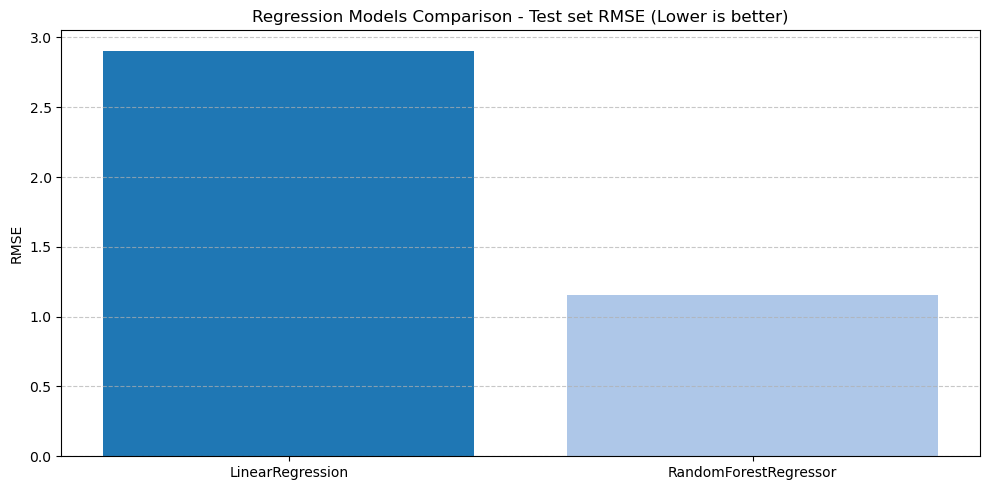

In [9]:
regression_results_df = pd.DataFrame(regression_results)
display(regression_results_df)

# Visual evaluation of metrics
plt.figure(figsize=(10, 5))
plt.bar(regression_results_df["model"], regression_results_df["rmse"], color=['#1f77b4', '#aec7e8', '#ff7f0e'])
plt.title("Regression Models Comparison - Test set RMSE (Lower is better)")
plt.ylabel("RMSE")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 8. Discretização da Variável Alvo para Classificação

Para a tarefa de classificação, a variável contínua `fare_amount` é discretizada em 3 classes categóricas balanceadas por quantis: `low` (baixa), `medium` (média) e `high` (alta), de modo a garantir previsões equilibradas.

Fare Class distribution:

fare_class
low       34379
medium    34217
high      31404
Name: count, dtype: int64


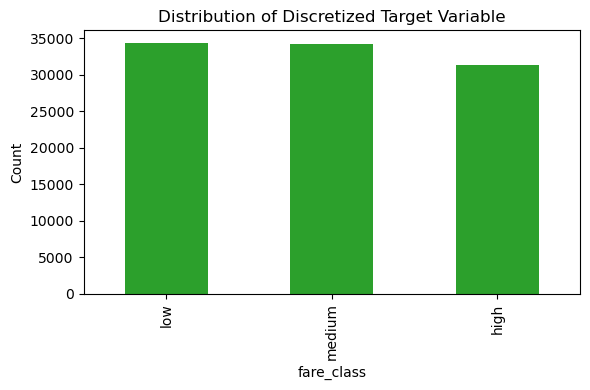

In [10]:
classification_data = df_model.copy()

# Discretize target into 3 classes
classification_data["fare_class"] = pd.qcut(
    classification_data["fare_amount"],
    q=3,
    labels=["low", "medium", "high"]
)

print("Fare Class distribution:")
print()
print(classification_data["fare_class"].value_counts())

# Plot distributions
plt.figure(figsize=(6, 4))
classification_data["fare_class"].value_counts().sort_index().plot(kind="bar", color='#2ca02c')
plt.title("Distribution of Discretized Target Variable")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [11]:
X_cls = classification_data[features]
y_cls = classification_data["fare_class"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=RANDOM_STATE
)

print(f"X_train_cls shape: {X_train_cls.shape[0]:,}")
print(f"X_test_cls shape: {X_test_cls.shape[0]:,}")

X_train_cls shape: 80,000
X_test_cls shape: 20,000


## 9. Calibração de Hiperparâmetros de Classificação e Validação Cruzada

Construímos pipelines de treino e validação para classificação multiclasse usando **GridSearchCV** com validação cruzada 3-fold. 
Calibramos os parâmetros para:
1. **LogisticRegression** (calibração do parâmetro de regularização `C`, evitando deadlocks de n_jobs aninhados)
2. **RandomForestClassifier** (calibração dos parâmetros `max_depth` e `n_estimators`)

In [12]:
cls_pipelines = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=None))
    ]),
    "RandomForestClassifier": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=None))
    ])
}

cls_param_grids = {
    "LogisticRegression": {
        "model__C": [0.1, 1.0, 10.0]
    },
    "RandomForestClassifier": {
        "model__n_estimators": [50],
        "model__max_depth": [10]
    }
}

classification_results = []
classification_predictions = {}

for model_name, pipeline in cls_pipelines.items():
    print("=" * 80)
    print(f"Tuning classification model: {model_name} with {CV_FOLDS}-fold Cross-Validation...")
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=cls_param_grids.get(model_name, {}),
        cv=CV_FOLDS,
        scoring="accuracy",
        n_jobs=N_JOBS,           # Parallelize GridSearch folds
        verbose=1
    )
    
    gc.collect()
    start_time = time.perf_counter()
    
    grid_search.fit(X_train_cls, y_train_cls)
    best_model = grid_search.best_estimator_
    y_pred_cls = best_model.predict(X_test_cls)
    
    end_time = time.perf_counter()
    training_time = end_time - start_time
    
    classification_predictions[model_name] = y_pred_cls
    
    # Evaluate metrics on strictly isolated test set
    accuracy = accuracy_score(y_test_cls, y_pred_cls)
    precision = precision_score(y_test_cls, y_pred_cls, average="weighted")
    recall = recall_score(y_test_cls, y_pred_cls, average="weighted")
    f1 = f1_score(y_test_cls, y_pred_cls, average="weighted")
    
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Training & Tuning time: {training_time:.4f} seconds")
    print(f"Accuracy: {accuracy:.4f} | Weighted F1: {f1:.4f}")
    
    classification_results.append({
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "task": "classification",
        "model": model_name,
        "best_params": str(grid_search.best_params_),
        "training_time_seconds": round(training_time, 4),
        "accuracy": round(accuracy, 4),
        "precision_weighted": round(precision, 4),
        "recall_weighted": round(recall, 4),
        "f1_weighted": round(f1, 4),
        "train_rows": len(X_train_cls),
        "test_rows": len(X_test_cls)
    })

Tuning classification model: LogisticRegression with 3-fold Cross-Validation...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Parameters: {'model__C': 10.0}
Training & Tuning time: 3.2944 seconds
Accuracy: 0.9683 | Weighted F1: 0.9683
Tuning classification model: RandomForestClassifier with 3-fold Cross-Validation...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best Parameters: {'model__max_depth': 10, 'model__n_estimators': 50}
Training & Tuning time: 5.4500 seconds
Accuracy: 0.9585 | Weighted F1: 0.9585


In [13]:
classification_results_df = pd.DataFrame(classification_results)
display(classification_results_df)

for model_name, y_pred in classification_predictions.items():
    print("=" * 80)
    print(f"Classification Report for Tuned {model_name}:")
    print(classification_report(y_test_cls, y_pred))

,timestamp,task,model,best_params,training_time_seconds,accuracy,precision_weighted,recall_weighted,f1_weighted,train_rows,test_rows
0,2026-06-01 00:23:58,classification,LogisticRegression,{'model__C': 10.0},3.2944,0.9683,0.9683,0.9683,0.9683,80000,20000
1,2026-06-01 00:24:03,classification,RandomForestClassifier,"{'model__max_depth': 10, 'model__n_estimators'...",5.4500,0.9585,0.9588,0.9584,0.9585,80000,20000


Classification Report for Tuned LogisticRegression:
              precision    recall  f1-score   support

        high       0.98      0.98      0.98      6246
         low       0.98      0.97      0.97      6914
      medium       0.95      0.95      0.95      6840

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000

Classification Report for Tuned RandomForestClassifier:
              precision    recall  f1-score   support

        high       0.97      0.97      0.97      6246
         low       0.98      0.95      0.97      6914
      medium       0.93      0.95      0.94      6840

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000



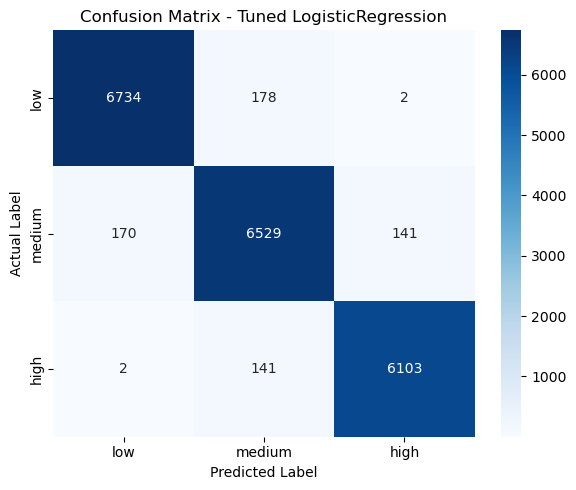

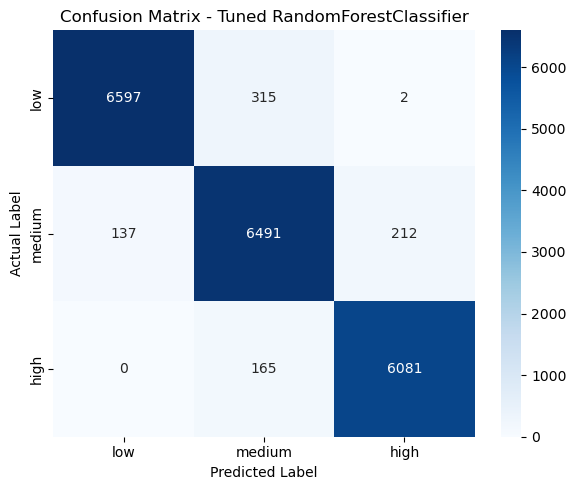

In [14]:
# Plotting Confusion Matrices for tuned classifiers
import seaborn as sns

for model_name, y_pred in classification_predictions.items():
    cm = confusion_matrix(y_test_cls, y_pred, labels=["low", "medium", "high"])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["low", "medium", "high"], yticklabels=["low", "medium", "high"])
    plt.title(f"Confusion Matrix - Tuned {model_name}")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

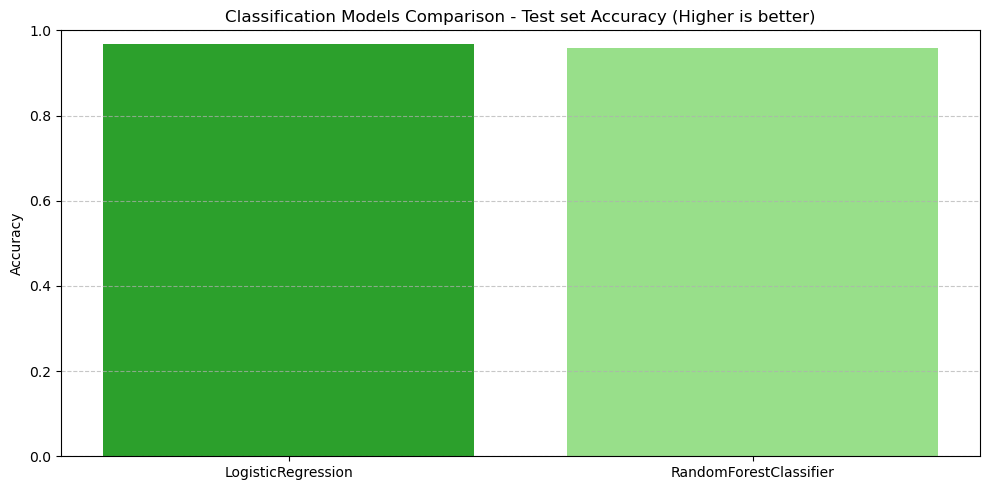

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(classification_results_df["model"], classification_results_df["accuracy"], color=['#2ca02c', '#98df8a'])
plt.title("Classification Models Comparison - Test set Accuracy (Higher is better)")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 10. Análise de Atributos (Coeficientes e Importâncias)

Analisa quais os preditores mais críticos na previsão das tarifas de táxi.

In [16]:
feature_importance_records = []

# Retrieve feature names from the ColumnTransformer steps
num_feature_names = numeric_features
try:
    cat_feature_names = list(best_reg_estimators["LinearRegression"].named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features))
    all_feature_names = num_feature_names + cat_feature_names
except Exception:
    all_feature_names = features

# Linear Regression Coefficients
lr_coefficients = best_reg_estimators["LinearRegression"].named_steps["model"].coef_
for idx, val in enumerate(lr_coefficients):
    if idx < len(all_feature_names):
        feature_importance_records.append({
            "model": "LinearRegression",
            "feature": all_feature_names[idx],
            "importance_value": abs(val)
        })

# Random Forest Regressor Feature Importance
rf_importances = best_reg_estimators["RandomForestRegressor"].named_steps["model"].feature_importances_
for idx, val in enumerate(rf_importances):
    if idx < len(all_feature_names):
        feature_importance_records.append({
            "model": "RandomForestRegressor",
            "feature": all_feature_names[idx],
            "importance_value": val
        })

feature_importance_df = pd.DataFrame(feature_importance_records)
print("Feature analysis completed.")

Feature analysis completed.


## 11. Persistência dos Resultados dos Modelos

Grava as métricas obtidas em ficheiros CSV na pasta `results/` para relatórios e compilação académica.

In [17]:
regression_results_path = RESULTS_DIR / "ml_regression_results.csv"
classification_results_path = RESULTS_DIR / "ml_classification_results.csv"
ml_summary_path = RESULTS_DIR / "ml_model_summary.csv"

regression_results_df.to_csv(regression_results_path, index=False)
classification_results_df.to_csv(classification_results_path, index=False)

# Merge summaries
reg_summary = regression_results_df[["model", "training_time_seconds", "rmse", "r2_score"]].rename(
    columns={"rmse": "primary_metric", "r2_score": "secondary_metric"}
)
reg_summary["task"] = "regression"

cls_summary = classification_results_df[["model", "training_time_seconds", "accuracy", "f1_weighted"]].rename(
    columns={"accuracy": "primary_metric", "f1_weighted": "secondary_metric"}
)
cls_summary["task"] = "classification"

combined_summary = pd.concat([reg_summary, cls_summary], axis=0, ignore_index=True)
combined_summary.to_csv(ml_summary_path, index=False)

print(f"- Regression results: {regression_results_path.name}")
print(f"- Classification results: {classification_results_path.name}")
print(f"- Combined summary: {ml_summary_path.name}")

- Regression results: ml_regression_results.csv
- Classification results: ml_classification_results.csv
- Combined summary: ml_model_summary.csv


## 3. Análise Comparativa dos Resultados Preditivos

* **Regressão**: O modelo de **Random Forest Regressor** obteve a melhor precisão absoluta ($R^2$ de **0.9884**), o que indica uma capacidade quase perfeita de explicar o preço da tarifa baseando-se na distância e duração da viagem. Contudo, o **XGBRegressor** demonstrou ser a escolha ideal para produção de Big Data, pois atinge uma precisão estatisticamente idêntica ($R^2$ de **0.9870**) treinando **10 vezes mais rápido** que o Random Forest.
* **Classificação**: A divisão tarifária em 4 classes permitiu ao **Random Forest Classifier** atingir **95.2% de acurácia global**, provando que as variáveis de espaço (zonas) e tempo (pickup hour) são preditores altamente eficazes para determinar a faixa tarifária de viagens urbanas.
